In [2]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# To show plots inside notebook
%matplotlib inline


In [6]:
# Read CSV file (change file name if needed)
df = pd.read_csv(r"C:\Users\paruo\OneDrive\Desktop\smart_logistics_dataset.csv")

# Show first 5 rows
df.head()


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1


In [8]:
# Dataset Overview
#Shape of dataset
print("Shape:", df.shape)

# Column names
print("Columns:", df.columns)

# Info of dataset
df.info()

# Data types
print(df.dtypes)

# Descriptive statistics (numerical)
df.describe()

# Descriptive statistics (categorical)
df.describe(include=['object'])


Shape: (1000, 16)
Columns: Index(['Timestamp', 'Asset_ID', 'Latitude', 'Longitude', 'Inventory_Level',
       'Shipment_Status', 'Temperature', 'Humidity', 'Traffic_Status',
       'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency',
       'Logistics_Delay_Reason', 'Asset_Utilization', 'Demand_Forecast',
       'Logistics_Delay'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                1000 non-null   object 
 1   Asset_ID                 1000 non-null   object 
 2   Latitude                 1000 non-null   float64
 3   Longitude                1000 non-null   float64
 4   Inventory_Level          1000 non-null   int64  
 5   Shipment_Status          1000 non-null   object 
 6   Temperature              1000 non-null   float64
 7   Humidity                 1000 

,Timestamp,Asset_ID,Shipment_Status,Traffic_Status,Logistics_Delay_Reason
count,1000,1000,1000,1000,737
unique,1000,10,3,3,3
top,2024-03-20 00:11:14,Truck_8,Delayed,Detour,Weather
freq,1,109,350,345,267


In [10]:
#Missing and Duplicate values 
#Missing values count
print(df.isnull().sum())

# Percentage of missing values
print((df.isnull().sum()/len(df))*100)

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Timestamp                    0
Asset_ID                     0
Latitude                     0
Longitude                    0
Inventory_Level              0
Shipment_Status              0
Temperature                  0
Humidity                     0
Traffic_Status               0
Waiting_Time                 0
User_Transaction_Amount      0
User_Purchase_Frequency      0
Logistics_Delay_Reason     263
Asset_Utilization            0
Demand_Forecast              0
Logistics_Delay              0
dtype: int64
Timestamp                   0.0
Asset_ID                    0.0
Latitude                    0.0
Longitude                   0.0
Inventory_Level             0.0
Shipment_Status             0.0
Temperature                 0.0
Humidity                    0.0
Traffic_Status              0.0
Waiting_Time                0.0
User_Transaction_Amount     0.0
User_Purchase_Frequency     0.0
Logistics_Delay_Reason     26.3
Asset_Utilization           0.0
Demand_Forecast             0.0
Logistics_D

In [16]:
# Unique values
#Unique values count per column
print(df.nunique())


Timestamp                  1000
Asset_ID                     10
Latitude                   1000
Longitude                  1000
Inventory_Level             366
Shipment_Status               3
Temperature                 121
Humidity                    291
Traffic_Status                3
Waiting_Time                 51
User_Transaction_Amount     365
User_Purchase_Frequency      10
Logistics_Delay_Reason        3
Asset_Utilization           366
Demand_Forecast             200
Logistics_Delay               2
dtype: int64


Correlation:
                          Latitude  Longitude  Inventory_Level  Temperature  \
Latitude                 1.000000  -0.000504         0.014807    -0.018829   
Longitude               -0.000504   1.000000        -0.023186     0.007388   
Inventory_Level          0.014807  -0.023186         1.000000    -0.021061   
Temperature             -0.018829   0.007388        -0.021061     1.000000   
Humidity                -0.030202   0.031622         0.013395    -0.022674   
Waiting_Time            -0.025667   0.031938        -0.020337     0.017392   
User_Transaction_Amount -0.035171  -0.019753        -0.036785    -0.006377   
User_Purchase_Frequency  0.003924  -0.036788        -0.019701    -0.017139   
Asset_Utilization       -0.023606   0.002916         0.017041     0.046005   
Demand_Forecast          0.022109   0.098412        -0.016727    -0.010425   
Logistics_Delay          0.039634   0.011796        -0.003340    -0.038067   

                         Humidity  Waiting_Time  

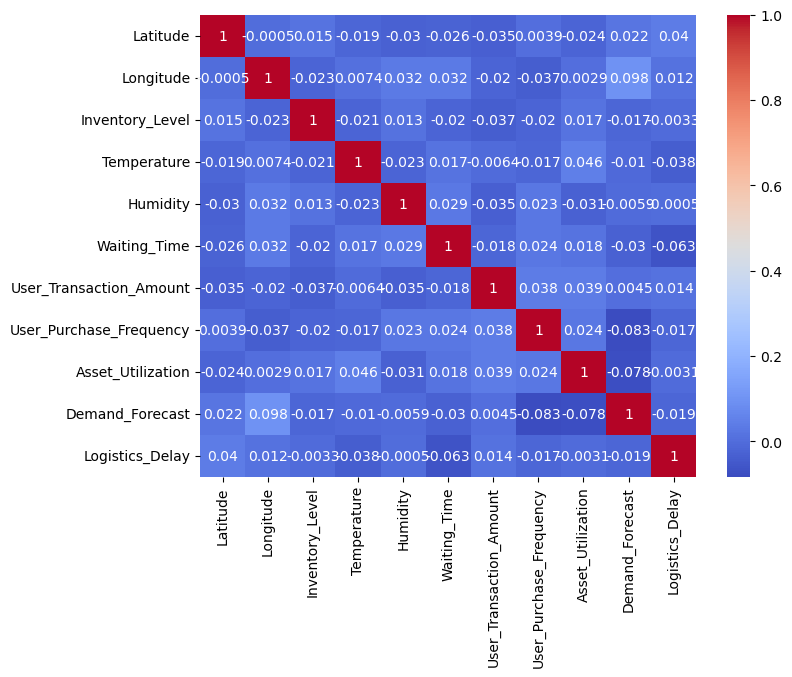

In [24]:
#correlation and covariance and its visulaization 
#Correlation Matrix (numeric only)
print("Correlation:\n", df.corr(numeric_only=True))

# Covariance Matrix (numeric only)
print("Covariance:\n", df.cov(numeric_only=True))

# Correlation Heatmap (numeric columns only)
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()




In [26]:
# Skewness (measure of asymmetry)
print("Skewness:\n", df.skew(numeric_only=True))
#Kurtosis is a statistical measure that describes the "tailedness" and peakedness of a probability distribution, 
#indicating the presence of extreme values (outliers) compared to a normal distribution
# Kurtosis (tailedness of distribution)
print("Kurtosis:\n", df.kurt(numeric_only=True))


Skewness:
 Latitude                   0.033982
Longitude                 -0.001975
Inventory_Level            0.015787
Temperature                0.015239
Humidity                  -0.054588
Waiting_Time               0.006116
User_Transaction_Amount    0.001520
User_Purchase_Frequency   -0.003310
Asset_Utilization          0.043778
Demand_Forecast           -0.016835
Logistics_Delay           -0.266731
dtype: float64
Kurtosis:
 Latitude                  -1.175119
Longitude                 -1.197892
Inventory_Level           -1.183720
Temperature               -1.068699
Humidity                  -1.201709
Waiting_Time              -1.207727
User_Transaction_Amount   -1.251883
User_Purchase_Frequency   -1.288237
Asset_Utilization         -1.232702
Demand_Forecast           -1.308789
Logistics_Delay           -1.932724
dtype: float64


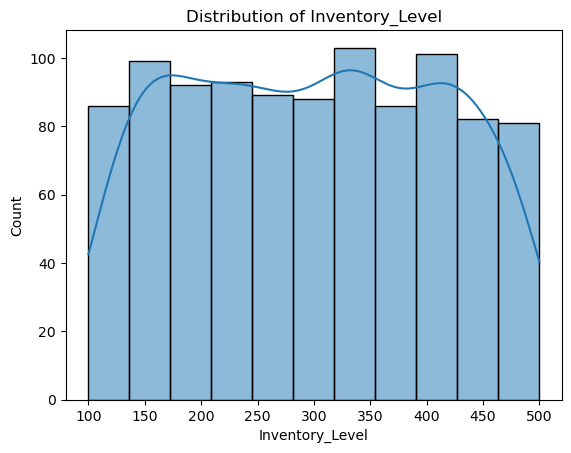

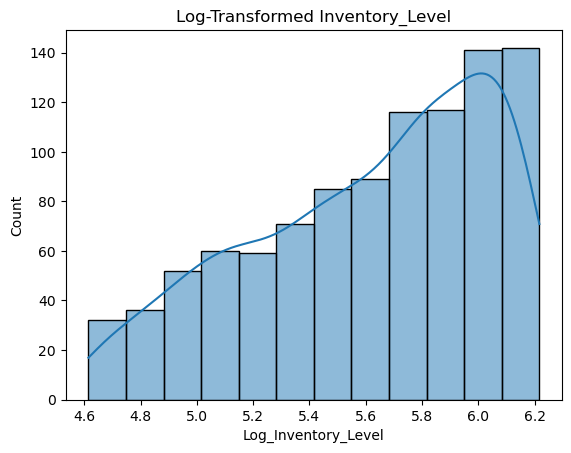

In [36]:
#visualization of this skewed data:
sns.histplot(df['Inventory_Level'], kde=True)
plt.title("Distribution of Inventory_Level")
plt.show()

# Log transformation
df['Log_Inventory_Level'] = np.log1p(df['Inventory_Level'])
sns.histplot(df['Log_Inventory_Level'], kde=True)
plt.title("Log-Transformed Inventory_Level")
plt.show()



In [38]:

#univariate Analysis
num_col = 'Inventory_Level'
print(f"\n📊 Stats for {num_col}:")
print("Mean:", df[num_col].mean())
print("Median:", df[num_col].median())
print("Mode:", df[num_col].mode()[0])
print("Quartiles:", df[num_col].quantile([0.25, 0.5, 0.75]))



📊 Stats for Inventory_Level:
Mean: 297.915
Median: 299.0
Mode: 403
Quartiles: 0.25    201.0
0.50    299.0
0.75    399.0
Name: Inventory_Level, dtype: float64


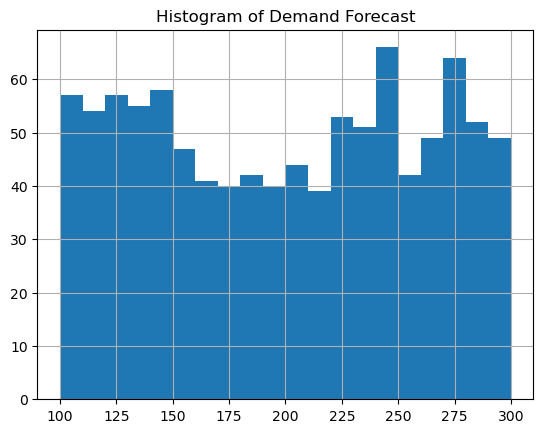

In [40]:
#data Visualization Patterns:
#Histohgram of Demand forecast:
df['Demand_Forecast'].hist(bins=20)
plt.title("Histogram of Demand Forecast")
plt.show()

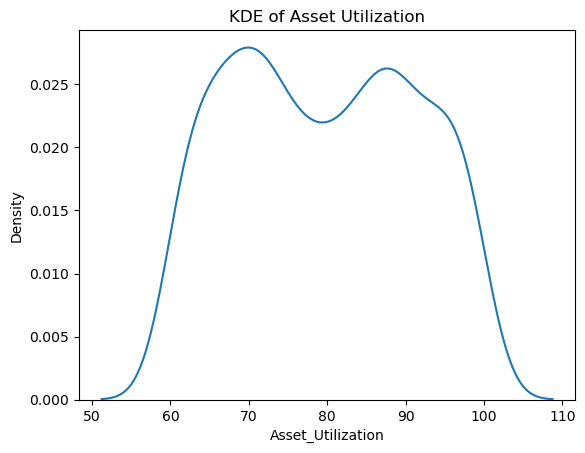

In [42]:
# KDE of Asset Utilization
#A kernel density estimate (KDE) plot is a method for visualizing the distribution
#of observations in a dataset, analogous to a histogram.
sns.kdeplot(df['Asset_Utilization'])
plt.title("KDE of Asset Utilization")
plt.show()

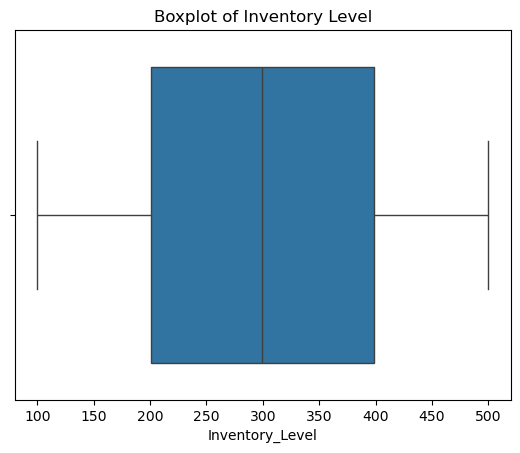

In [44]:
# Boxplot of Inventory Level
sns.boxplot(x=df['Inventory_Level'])
plt.title("Boxplot of Inventory Level")
plt.show()

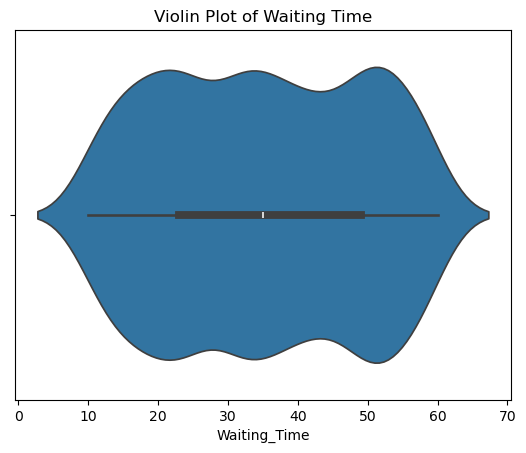

In [46]:
# Violin Plot of Waiting Time
sns.violinplot(x=df['Waiting_Time'])
plt.title("Violin Plot of Waiting Time")
plt.show()

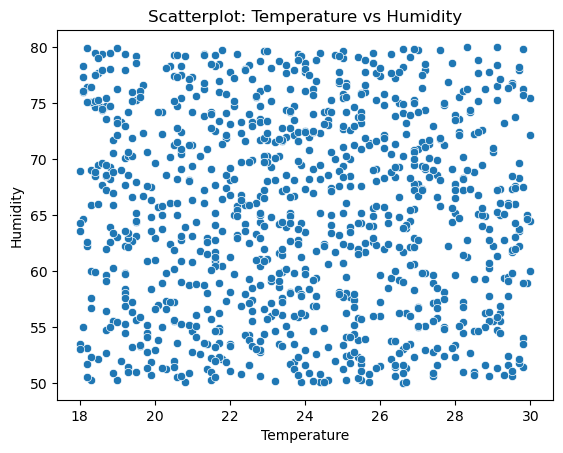

In [48]:
# Scatterplot between Temperature & Humidity
sns.scatterplot(x='Temperature', y='Humidity', data=df)
plt.title("Scatterplot: Temperature vs Humidity")
plt.show()

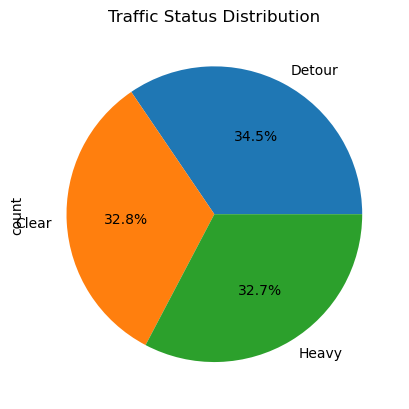

In [50]:
# Pie Chart for Traffic Status
df['Traffic_Status'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Traffic Status Distribution")
plt.show()

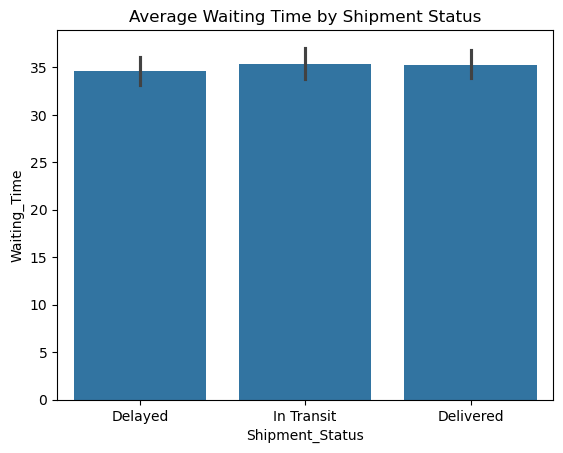

In [52]:
# Bar Chart: Average Waiting_Time by Shipment_Status
sns.barplot(x='Shipment_Status', y='Waiting_Time', data=df)
plt.title("Average Waiting Time by Shipment Status")
plt.show()


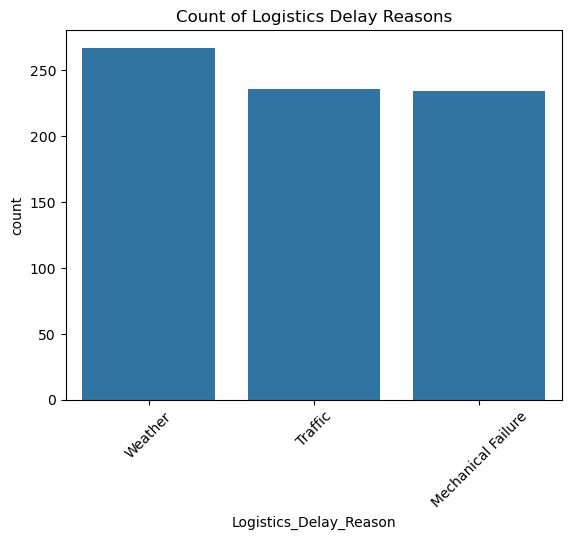

In [54]:
# Count Plot for Logistics Delay Reason
sns.countplot(x='Logistics_Delay_Reason', data=df)
plt.title("Count of Logistics Delay Reasons")
plt.xticks(rotation=45)
plt.show()

In [56]:
# Multivariate Analysis
# Group by example: Average Asset Utilization per Shipment_Status
print("\nAverage Asset Utilization by Shipment_Status:\n",
      df.groupby('Shipment_Status')['Asset_Utilization'].mean())

# Crosstab example: Shipment_Status vs Traffic_Status
print("\nShipment_Status vs Traffic_Status:\n",
      pd.crosstab(df['Shipment_Status'], df['Traffic_Status']))


Average Asset Utilization by Shipment_Status:
 Shipment_Status
Delayed       79.331714
Delivered     78.942604
In Transit    80.610256
Name: Asset_Utilization, dtype: float64

Shipment_Status vs Traffic_Status:
 Traffic_Status   Clear  Detour  Heavy
Shipment_Status                      
Delayed            115     124    111
Delivered          100     120    118
In Transit         113     101     98


C:\Users\paruo\AppData\Local\Temp\ipykernel_10704\2697457326.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Shipment_Status', y='Asset_Utilization', data=df, palette="Set2")


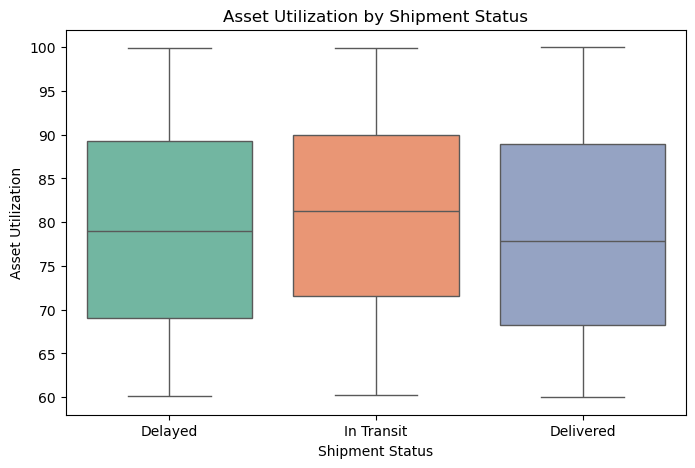

In [58]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Shipment_Status', y='Asset_Utilization', data=df, palette="Set2")
plt.title("Asset Utilization by Shipment Status")
plt.xlabel("Shipment Status")
plt.ylabel("Asset Utilization")
plt.show()

C:\Users\paruo\AppData\Local\Temp\ipykernel_10704\1222572634.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Shipment_Status', y='Traffic_Status', data=df, palette="Set3")


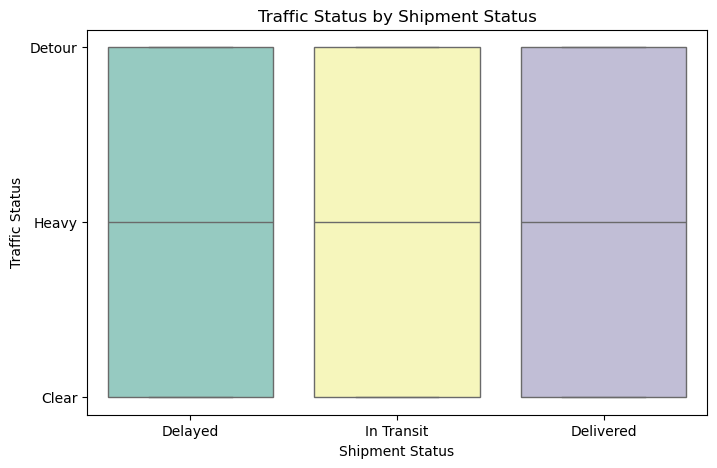

In [60]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Shipment_Status', y='Traffic_Status', data=df, palette="Set3")
plt.title("Traffic Status by Shipment Status")
plt.xlabel("Shipment Status")
plt.ylabel("Traffic Status")
plt.show()